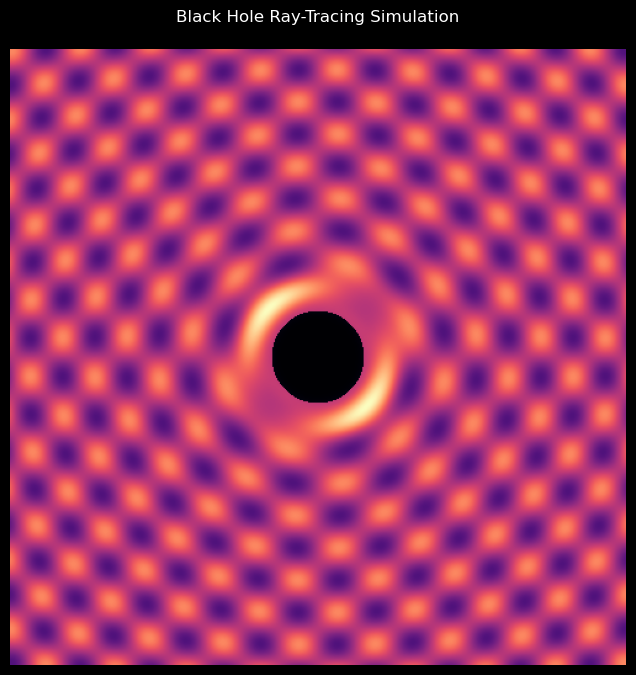

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_black_hole(resolution=500):
    # 1. Create a coordinate grid
    x = np.linspace(-2, 2, resolution)
    y = np.linspace(-2, 2, resolution)
    X, Y = np.meshgrid(x, y)
    
    # 2. Polar coordinates (distance from center r, angle theta)
    r = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(Y, X)
    
    # 3. Define the Schwarzschild Radius (Event Horizon)
    rs = 0.3
    
    # 4. Calculate the warping (Einstein Ring effect)
    # Light near the event horizon is deflected infinitely.
    # Outside, it follows the bending rule: beta = theta * (1 - rs/r)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Mapping function: how the background is pulled toward the center
        # This is a simplified version of the lens equation
        warped_r = r * (1 - rs / r)
    
    # 5. Create a "Background" (a grid of stars/lines)
    # We use a sine wave pattern to create a checkerboard/grid
    grid_size = 15
    background = np.sin(grid_size * warped_r * np.cos(theta)) * \
                 np.sin(grid_size * warped_r * np.sin(theta))
    
    # 6. Apply the Event Horizon (The "Black" part)
    # Anything inside the Schwarzschild radius is pitch black
    background[r <= rs] = -2  # Solid black
    
    # 7. Add a "Photon Sphere" glow effect
    photon_sphere = rs * 1.5
    glow = np.exp(-((r - photon_sphere)**2) / 0.01)
    final_image = background + glow

    # 8. Visualization
    plt.figure(figsize=(8, 8), facecolor='black')
    plt.imshow(final_image, extent=[-2, 2, -2, 2], cmap='magma')
    plt.axis('off')
    plt.title("Black Hole Ray-Tracing Simulation", color='white', pad=20)
    plt.show()

if __name__ == "__main__":
    simulate_black_hole()